In [ ]:
import kagglehub
path = kagglehub.dataset_download("shahriar26s/banana-ripeness-classification-dataset")

100%|██████████| 221M/221M [00:06<00:00, 37.7MB/s]

Extracting files...


In [ ]:
## LAYER1-image classification
import os

dataset_root = os.path.join(path, "Banana Ripeness Classification Dataset")
print(os.listdir(dataset_root))

['train', 'valid', 'test']


In [ ]:
train_path = os.path.join(dataset_root, "train")
val_path   = os.path.join(dataset_root, "valid")   # or "dev" if named differently
test_path  = os.path.join(dataset_root, "test")

print("Train classes:", os.listdir(train_path))

Train classes: ['unripe', 'overripe', 'ripe', 'rotten']


In [ ]:
for split_name, split_path in [("Train", train_path),
                               ("Validation", val_path),
                               ("Test", test_path)]:
    print(f"\n{split_name}:")
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        print(cls, len(os.listdir(cls_path)))


Train:
unripe 1902
overripe 2349
ripe 3522
rotten 4020

Validation:
unripe 167
overripe 229
ripe 339
rotten 388

Test:
unripe 110
overripe 113
ripe 154
rotten 185


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
dataset_root = os.path.join(path, "Banana Ripeness Classification Dataset")

train_path = os.path.join(dataset_root, "train")
val_path   = os.path.join(dataset_root, "valid")
test_path  = os.path.join(dataset_root, "test")

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 11793 files belonging to 4 classes.
Found 1123 files belonging to 4 classes.
Found 562 files belonging to 4 classes.
Classes: ['overripe', 'ripe', 'rotten', 'unripe']
Number of classes: 4


In [ ]:
labels = np.concatenate([y for x, y in train_ds], axis=0)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.2551085568326947), 1: np.float64(0.8370954003407155), 2: np.float64(0.7333955223880597), 3: np.float64(1.5500788643533123)}


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

normalization_layer = layers.Lambda(preprocess_input)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import tensorflow as tf

IMG_SIZE = 224
num_classes = 4

# Input layer
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Backbone
base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs
)

base_model.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs=inputs, outputs=outputs)

/tmp/ipython-input-390/2351951309.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(patience=2)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 68s 127ms/step - accuracy: 0.6956 - loss: 0.8451 - val_accuracy: 0.8896 - val_loss: 0.3077 - learning_rate: 0.0010
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.8424 - loss: 0.4089 - val_accuracy: 0.8923 - val_loss: 0.2930 - learning_rate: 0.0010
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.8722 - loss: 0.3284 - val_accuracy: 0.9234 - val_loss: 0.2361 - learning_rate: 0.0010
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.8842 - loss: 0.2927 - val_accuracy: 0.9207 - val_loss: 0.2431 - learning_rate: 0.0010
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.8931 - loss: 0.2654 - val_accuracy: 0.9136 - val_loss: 0.2559 - learning_rate: 0.0010
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9075 - loss: 0.2434 - val_accuracy: 0.9261 - val_loss: 0.2274 - learning_rate: 1.0000e-04
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.919

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

Epoch 1/8
369/369 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.9331 - loss: 0.1787 - val_accuracy: 0.9305 - val_loss: 0.2092
Epoch 2/8
369/369 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9345 - loss: 0.1737 - val_accuracy: 0.9314 - val_loss: 0.2084
Epoch 3/8
369/369 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.9376 - loss: 0.1766 - val_accuracy: 0.9305 - val_loss: 0.2083
Epoch 4/8
369/369 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9335 - loss: 0.1789 - val_accuracy: 0.9323 - val_loss: 0.2083
Epoch 5/8
369/369 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.9378 - loss: 0.1706 - val_accuracy: 0.9332 - val_loss: 0.2080
Epoch 6/8
369/369 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9364 - loss: 0.1732 - val_accuracy: 0.9350 - val_loss: 0.2068
Epoch 7/8
369/369 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9390 - loss: 0.1674 - val_accuracy: 0.9341 - val_loss: 0.2064
Epoch 8/8
369/369 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9394 - loss: 0.1671 - val_accu

In [ ]:
model.evaluate(test_ds)

18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 722ms/step - accuracy: 0.9353 - loss: 0.1678


[0.17899124324321747, 0.9270462393760681]

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 348ms/step
              precision    recall  f1-score   support

    overripe       0.94      0.97      0.96       113
        ripe       0.94      0.86      0.90       154
      rotten       0.89      0.94      0.91       185
      unripe       0.96      0.95      0.95       110

    accuracy                           0.93       562
   macro avg       0.93      0.93      0.93       562
weighted avg       0.93      0.93      0.93       562



In [ ]:
model.save("ripeness_model.keras")

In [ ]:
from google.colab import files
files.download("ripeness_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

with open("ripeness_metadata.json", "w") as f:
    json.dump({"class_names": class_names}, f)

In [ ]:
## LAYER 2-synthetic data Layer 2 — Spoilage & Waste Prediction Engine
##unripe = 0
##ripe = 1
##overripe = 2
##rotten = 3

In [ ]:
import numpy as np
import pandas as pd
import random

np.random.seed(42)

# -----------------------------
# Configuration
# -----------------------------
n_samples = 20000

fruit_types = ["banana"]  # Later add: "apple", "tomato"

ripeness_map = {
    "unripe": 0,
    "ripe": 1,
    "overripe": 2,
    "rotten": 3
}

data = []

# -----------------------------
# Generate Data
# -----------------------------
for _ in range(n_samples):

    fruit = random.choice(fruit_types)

    ripeness_label = random.choice(list(ripeness_map.keys()))
    ripeness_stage = ripeness_map[ripeness_label]

    temperature = np.random.uniform(10, 35)       # °C
    humidity = np.random.uniform(40, 90)          # %
    quantity = np.random.uniform(20, 200)         # kg
    sales_velocity = np.random.uniform(5, 50)     # kg/day
    days_in_storage = np.random.randint(1, 10)

    # -----------------------------
    # Spoilage Formula (Domain Logic)
    # -----------------------------
    base = 0.05

    temperature_factor = 0.02 * (temperature - 15)
    humidity_factor = 0.005 * (humidity - 50)
    ripeness_factor = 0.15 * ripeness_stage
    storage_factor = 0.03 * days_in_storage
    sales_factor = -0.02 * (sales_velocity / 10)

    spoilage_probability = (
        base
        + temperature_factor
        + humidity_factor
        + ripeness_factor
        + storage_factor
        + sales_factor
    )

    spoilage_probability = np.clip(spoilage_probability, 0, 1)

    expected_waste = spoilage_probability * quantity

    data.append([
        fruit,
        ripeness_stage,
        temperature,
        humidity,
        quantity,
        sales_velocity,
        days_in_storage,
        spoilage_probability,
        expected_waste
    ])

# -----------------------------
# Create DataFrame
# -----------------------------
columns = [
    "fruit",
    "ripeness_stage",
    "temperature",
    "humidity",
    "quantity",
    "sales_velocity",
    "days_in_storage",
    "spoilage_probability",
    "expected_waste_kg"
]

df = pd.DataFrame(data, columns=columns)

df.head()

,fruit,ripeness_stage,temperature,humidity,quantity,sales_velocity,days_in_storage,spoilage_probability,expected_waste_kg
0,banana,3,19.363503,87.535715,151.758910,31.939632,7,0.921069,139.780484
1,banana,2,21.145819,44.998746,102.664801,20.016888,8,0.647876,66.514094
2,banana,1,27.701814,41.029225,194.583773,42.459919,6,0.504263,98.121315
3,banana,0,10.019469,89.610578,131.146672,32.524392,9,0.353393,46.346380
4,banana,3,17.280729,70.592645,45.108895,18.146509,3,0.702285,31.679290


In [ ]:
df.describe()

,ripeness_stage,temperature,humidity,quantity,sales_velocity,days_in_storage,spoilage_probability,expected_waste_kg
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,1.506550,22.513057,65.042293,110.294866,27.489813,5.001500,0.592543,65.559822
std,1.119071,7.250099,14.392715,51.780910,12.975928,2.585949,0.238394,42.764236
min,0.000000,10.001188,40.000465,20.020720,5.002166,1.000000,0.000000,0.000000
25%,1.000000,16.199146,52.605849,65.627777,16.180285,3.000000,0.420283,30.857438
50%,1.000000,22.560473,65.098817,110.355449,27.535178,5.000000,0.597382,57.262730
75%,3.000000,28.817980,77.513398,154.862481,38.713498,7.000000,0.772646,92.969996
max,3.000000,34.997492,89.998693,199.982176,49.998919,9.000000,1.000000,199.625432


In [ ]:
df.to_csv("synthetic_retail_dataset.csv", index=False)

In [ ]:
import pandas as pd

df = pd.read_csv("synthetic_retail_dataset.csv")

df.head()

,fruit,ripeness_stage,temperature,humidity,quantity,sales_velocity,days_in_storage,spoilage_probability,expected_waste_kg
0,banana,3,19.363503,87.535715,151.758910,31.939632,7,0.921069,139.780484
1,banana,2,21.145819,44.998746,102.664801,20.016888,8,0.647876,66.514094
2,banana,1,27.701814,41.029225,194.583773,42.459919,6,0.504263,98.121315
3,banana,0,10.019469,89.610578,131.146672,32.524392,9,0.353393,46.346380
4,banana,3,17.280729,70.592645,45.108895,18.146509,3,0.702285,31.679290


In [ ]:
X = df[[
    "ripeness_stage",
    "temperature",
    "humidity",
    "quantity",
    "sales_velocity",
    "days_in_storage"
]]

y = df[[
    "spoilage_probability",
    "expected_waste_kg"
]]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

reg_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

reg_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = reg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.034246993643542
RMSE: 3.800553200596481


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = reg_model.predict(X_test)

mae_spoilage = mean_absolute_error(y_test["spoilage_probability"], y_pred[:,0])
mae_waste = mean_absolute_error(y_test["expected_waste_kg"], y_pred[:,1])

print("MAE Spoilage Probability:", mae_spoilage)
print("MAE Expected Waste (kg):", mae_waste)

MAE Spoilage Probability: 0.03823545042063107
MAE Expected Waste (kg): 4.030258536866462


In [ ]:
from sklearn.metrics import r2_score

r2_spoilage = r2_score(y_test["spoilage_probability"], y_pred[:,0])
r2_waste = r2_score(y_test["expected_waste_kg"], y_pred[:,1])

print("R2 Spoilage:", r2_spoilage)
print("R2 Waste:", r2_waste)

R2 Spoilage: 0.9587681000916931
R2 Waste: 0.9838478423288288


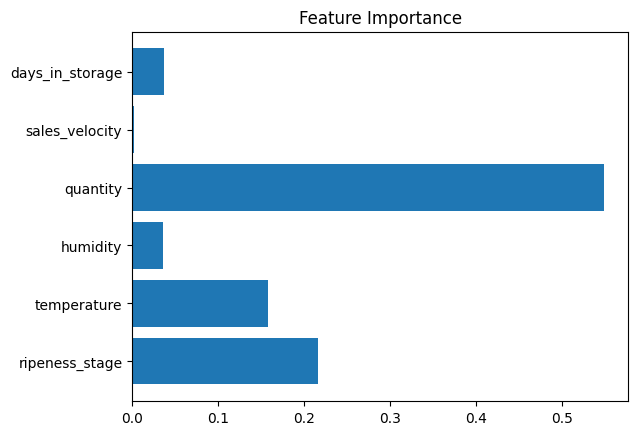

In [ ]:
import matplotlib.pyplot as plt

importances = reg_model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [ ]:
def pricing_engine(spoilage_probability):
    if spoilage_probability > 0.75:
        return 35
    elif spoilage_probability > 0.5:
        return 20
    elif spoilage_probability > 0.3:
        return 10
    else:
        return 5

In [ ]:
import numpy as np

# ----------------------------
# Intelligent Discount Formula
# ----------------------------

def simulate_optimal_discount(row):

    spoilage = row["spoilage_probability"]
    waste = row["expected_waste_kg"]
    quantity = row["quantity"]
    sales_velocity = row["sales_velocity"]

    # Core spoilage pressure
    spoilage_component = spoilage * 40

    # Inventory pressure
    inventory_component = (quantity / 200) * 10

    # Demand resistance
    demand_component = - (sales_velocity / 50) * 8

    # Waste amplification
    waste_component = (waste / 200) * 10

    discount = (
        5
        + spoilage_component
        + inventory_component
        + waste_component
        + demand_component
    )

    return np.clip(discount, 0, 50)


df["optimal_discount_percent"] = df.apply(simulate_optimal_discount, axis=1)

df.head()

,fruit,ripeness_stage,temperature,humidity,quantity,sales_velocity,days_in_storage,spoilage_probability,expected_waste_kg,optimal_discount_percent
0,banana,3,19.363503,87.535715,151.758910,31.939632,7,0.921069,139.780484,50.000000
1,banana,2,21.145819,44.998746,102.664801,20.016888,8,0.647876,66.514094,36.171296
2,banana,1,27.701814,41.029225,194.583773,42.459919,6,0.504263,98.121315,33.012170
3,banana,0,10.019469,89.610578,131.146672,32.524392,9,0.353393,46.346380,22.806489
4,banana,3,17.280729,70.592645,45.108895,18.146509,3,0.702285,31.679290,34.027359


In [ ]:
df["optimal_discount_percent"].describe()

,optimal_discount_percent
count,20000.000000
mean,32.707455
std,11.392416
min,0.000000
25%,24.463346
50%,32.980648
75%,41.847363
max,50.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# Features for pricing
pricing_features = df[[
    "spoilage_probability",
    "expected_waste_kg",
    "quantity",
    "sales_velocity"
]]

pricing_target = df["optimal_discount_percent"]

X_train, X_test, y_train, y_test = train_test_split(
    pricing_features,
    pricing_target,
    test_size=0.2,
    random_state=42
)

pricing_model = GradientBoostingRegressor()
pricing_model.fit(X_train, y_train)

y_pred = pricing_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.9981713666831273
MAE: 0.3818072123979043


In [ ]:
import joblib
import json

joblib.dump(pricing_model, "pricing_model.pkl")

pricing_meta = {
    "features": list(pricing_features.columns),
    "target": "optimal_discount_percent"
}

with open("pricing_metadata.json", "w") as f:
    json.dump(pricing_meta, f)

In [ ]:
import os

os.makedirs("models", exist_ok=True)

In [ ]:
import numpy as np
import pandas as pd

class SmartRetailSystem:

    def __init__(self):
        import tensorflow as tf
        import joblib
        import json
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

        self.vision = tf.keras.models.load_model(
            "models/ripeness_model.keras",
            custom_objects={"preprocess_input": preprocess_input}
        )

        self.regression = joblib.load("models/spoilage_model.pkl")

        with open("models/ripeness_metadata.json") as f:
            self.class_names = json.load(f)["class_names"]

    # -------------------------
    # Profit Optimization Engine
    # -------------------------
    def optimize_discount(self, spoilage_prob, expected_waste,
                          quantity, base_sales_velocity,
                          base_price=100, cost_price=60):

        import numpy as np

        best_profit = -np.inf
        best_discount = 0

        # Try discounts from 0% to 50%
        for discount in range(0, 51):

            discount_rate = discount / 100

            # Adjusted selling price
            selling_price = base_price * (1 - discount_rate)

            # Simulate demand increase due to discount
            demand_multiplier = 1 + (discount_rate * 2)   # elasticity factor
            adjusted_sales = base_sales_velocity * demand_multiplier

            # Cannot sell more than inventory
            sold_quantity = min(quantity, adjusted_sales)

            # Revenue
            sold_quantity = min(quantity, adjusted_sales)

            unsold_quantity = quantity - sold_quantity

            revenue = sold_quantity * selling_price

            cost_of_goods_sold = sold_quantity * cost_price

            waste_loss = unsold_quantity * cost_price

            profit = revenue - cost_of_goods_sold - waste_loss

            if profit > best_profit:
                best_profit = profit
                best_discount = discount

        return best_discount, best_profit

    # -------------------------
    # Full Prediction Pipeline
    # -------------------------
    def predict(self, image_array, temperature, humidity,
            quantity, sales_velocity, days):



      # -------------------------
      # Layer 1: Vision
      # -------------------------
      image_array = np.expand_dims(image_array, axis=0)
      preds = self.vision.predict(image_array, verbose=0)

      stage_index = np.argmax(preds)
      stage_label = self.class_names[stage_index]
      confidence = float(np.max(preds))

      # -------------------------
      # Confidence Gate
      # -------------------------
      CONFIDENCE_THRESHOLD = 0.75

      if confidence < CONFIDENCE_THRESHOLD:
          return {
              "status": "Low Confidence – Manual Review Required",
              "predicted_stage": stage_label,
              "confidence": confidence
          }

      # -------------------------
      # Layer 2: Spoilage
      # -------------------------
      features_l2 = pd.DataFrame([{
          "ripeness_stage": stage_index,
          "temperature": temperature,
          "humidity": humidity,
          "quantity": quantity,
          "sales_velocity": sales_velocity,
          "days_in_storage": days
      }])

      spoilage_prob, expected_waste = self.regression.predict(features_l2)[0]

      # -------------------------
      # Layer 3: Profit Optimization
      # -------------------------
      best_discount, best_profit = self.optimize_discount(
          spoilage_prob,
          expected_waste,
          quantity,
          sales_velocity
      )

      return {
          "status": "Prediction Successful",
          "ripeness_stage": stage_label,
          "confidence": confidence,
          "spoilage_probability": float(spoilage_prob),
          "expected_waste_kg": float(expected_waste),
          "optimal_discount_percent": best_discount,
          "estimated_profit": float(best_profit)
      }

In [ ]:
%who

BATCH_SIZE	 EarlyStopping	 GradientBoostingRegressor	 IMG_SIZE	 MobileNetV2	 RandomForestRegressor	 ReduceLROnPlateau	 SmartRetailSystem	 X	 
X_test	 X_train	 base	 base_model	 callbacks	 class_names	 class_weights	 classification_report	 cls	 
cls_path	 columns	 compute_class_weight	 data	 data_augmentation	 dataset_root	 days_in_storage	 df	 expected_waste	 
f	 features	 files	 fruit	 fruit_types	 history	 humidity	 humidity_factor	 importances	 
inputs	 joblib	 json	 kagglehub	 labels	 layers	 mae	 mae_spoilage	 mae_waste	 
mean_absolute_error	 mean_squared_error	 model	 models	 n_samples	 normalization_layer	 np	 num_classes	 os	 
outputs	 path	 pd	 plt	 prediction_metadata	 preprocess_input	 pricing_engine	 pricing_features	 pricing_meta	 
pricing_model	 pricing_target	 quantity	 r2_score	 r2_spoilage	 r2_waste	 random	 reg_model	 ripeness_factor	 
ripeness_label	 ripeness_map	 ripeness_metadata	 ripeness_stage	 rmse	 sales_factor	 sales_velocity	 simulate_optimal_discount	 split_

In [ ]:
import joblib

joblib.dump(reg_model, "spoilage_model.pkl")

['spoilage_model.pkl']

In [ ]:
joblib.dump(pricing_model, "pricing_model.pkl")

['pricing_model.pkl']

In [ ]:
import json

ripeness_metadata = {
    "class_names": class_names,   # ['unripe','overripe','rotten','ripe']
    "img_size": 224
}

with open("ripeness_metadata.json", "w") as f:
    json.dump(ripeness_metadata, f)

In [ ]:
prediction_metadata = {
    "feature_order": [
        "ripeness_stage",
        "temperature",
        "humidity",
        "quantity",
        "sales_velocity",
        "days_in_storage"
    ]
}

with open("prediction_metadata.json", "w") as f:
    json.dump(prediction_metadata, f)

In [ ]:
from google.colab import files

files.download("spoilage_model.pkl")
files.download("pricing_model.pkl")
files.download("ripeness_metadata.json")
files.download("prediction_metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image
import numpy as np

# Replace with your uploaded filename
image_path = "/content/banana.png"

image = Image.open(image_path).convert("RGB")
image = image.resize((224, 224))

image_array = np.array(image).astype("float32")
image_array = np.expand_dims(image_array, axis=0)

print("Shape:", image_array.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/banana.png'

In [ ]:
system = SmartRetailSystem()

result = system.predict(
    image_array,
    temperature=25,
    humidity=60,
    quantity=120,
    sales_velocity=20,
    days=4
)

print(result)